In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

K: 1.3347016023842098 (mm/s), erreur K: +/- 0.046953096498998696
k: 1.3632786494336378e-10 (m^2), erreur k: +/- 1.5321270476444562e-12


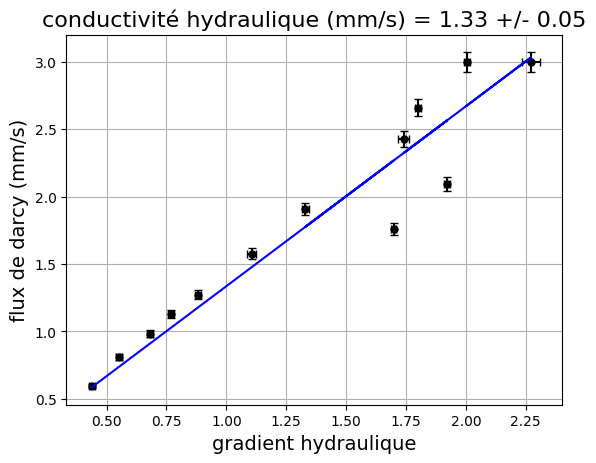

In [5]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(mm/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique',fontsize=14)
ax.set_ylabel('flux de darcy (mm/s)',fontsize=14)
ax.grid()

#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K} (mm/s), erreur K: +/- {K_err}")
ax.set_title(f"conductivité hydraulique (mm/s) = {K:.2f} +/- {K_err:.2f}",fontsize=16)

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
mu_err, rho_err = 0.0001, 1
K_m, K_err_m = K/1000, K_err/1000
k = K_m * mu / g / rho
k_err = k*((K_err_m/K_m)**2+(mu_err/mu)**2+(rho_err/rho)**2)
print (f"k: {k} (m^2), erreur k: +/- {k_err}")

plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/K.eps")

K: 1.4530382921411917 (mm/s), erreur K: +/- 0.012853341117678406
k: 1.4841490239819004e-07 (m^2), erreur k: +/- 1.495911329351743e-09


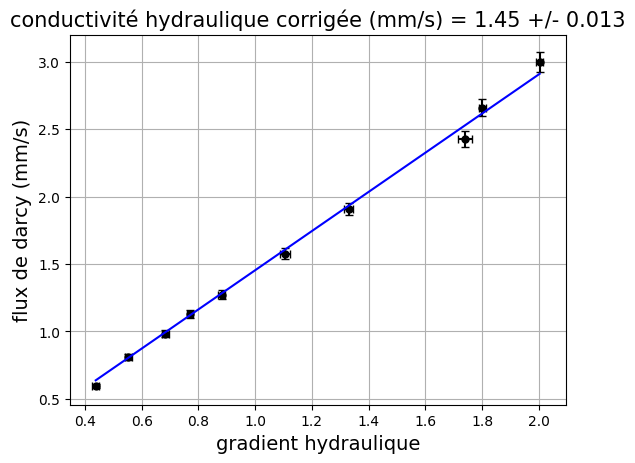

In [6]:
darcy_url = 'https://raw.githubusercontent.com/onillonn/TP_geologie/main/loi_darcy_corrige.xlsx'
darcy = pd.read_excel(darcy_url)
Q = darcy['débit_(m^3/s)'].dropna()
q = darcy['flux_Darcy_(mm/s)'].dropna()
q_err = darcy['erreur_q'].dropna()
i = darcy['gradient'].dropna()
i_err = darcy['erreur_i'].dropna()

#graphe
fig, ax = plt.subplots()
ax.plot(i,q,'k',marker='o', linestyle='none',linewidth=0,markersize=5)
ax.errorbar(i,q,yerr=[q_err],xerr=[i_err],c='k',linestyle='none',capsize=3)
ax.set_xlabel('gradient hydraulique',fontsize=14)
ax.set_ylabel('flux de darcy (mm/s)',fontsize=14)
ax.grid()

#ligne de régression, K
from scipy.optimize import curve_fit
def function_for_fit(x,a): #fonction à ajouter, x est la variable, a le paramètre
    return a*x
popt,pcov = curve_fit(function_for_fit,i,q)
K = popt.squeeze()
K_err = np.sqrt(pcov).squeeze()
ax.plot(i,function_for_fit(i,K),'b')
print (f"K: {K} (mm/s), erreur K: +/- {K_err}")
ax.set_title(f"conductivité hydraulique corrigée (mm/s) = {K:.2f} +/- {K_err:.3f}",fontsize=15)

#perméabilité intrinsèque
mu, rho, g = 0.001, 998, 9.81
mu_err, rho_err = 0.0001, 1
K_m, K_err_m = K/1000, K_err/1000
k = K * mu / g / rho
k_err = k*((K_err_m/K_m)**2+(mu_err/mu)**2+(rho_err/rho)**2)
print (f"k: {k} (m^2), erreur k: +/- {k_err}")

plt.savefig("C:/Users/Nicolas Onillon/PycharmProjects/TP_geologie/K_corrigé.eps")